# Multivariable Regression: Building Up a Model for HDB Resale Prices

50,718 HDB resale transactions from May 2024 to April 2026 (most recent 2 years). We use a 2-year window because regression assumes stable relationships across all rows — over 35 years of data, policy regime changes and nominal inflation break that assumption.

We build ten progressively richer models predicting `resale_price` (raw dollars), adding variables one group at a time and using ANOVA to test each addition. HC1 robust standard errors throughout.

In [47]:
# Python setup
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
%%R
library(tidyverse)
library(broom)
library(scales)
library(stargazer)
library(sandwich)
library(lmtest)

In [49]:
%%R
df <- read_csv('data/hdb_analysis.csv', show_col_types = FALSE)
cat(sprintf("Loaded %s rows and %s columns\n", comma(nrow(df)), ncol(df)))
cat(sprintf("Any NAs in key columns: %s\n", any(is.na(df %>% select(resale_price, town, flat_type, floor_area_sqm, storey_mid, remaining_lease_years, flat_model_grouped, ends_in_8)))))

Loaded 50,718 rows and 63 columns
Any NAs in key columns: FALSE


---
## Model 1: Town + Flat Type

Start with location and flat category — the two most obvious price drivers.

In [50]:
%%R
model1 <- lm(resale_price ~ town + flat_type, data = df)

s1 <- summary(model1)
cat(sprintf("Model 1: town + flat_type\n"))
cat(sprintf("R-squared:     %.4f\n", s1$r.squared))
cat(sprintf("Adj R-squared: %.4f\n", s1$adj.r.squared))

Model 1: town + flat_type
R-squared:     0.6322
Adj R-squared: 0.6320


---
## Model 2: + Floor Area + Storey

Add physical characteristics: how big is the flat, and how high up?

In [51]:
%%R
model2 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid, data = df)

s2 <- summary(model2)
cat(sprintf("Model 2: + floor_area_sqm + storey_mid\n"))
cat(sprintf("R-squared:     %.4f\n", s2$r.squared))
cat(sprintf("Adj R-squared: %.4f\n", s2$adj.r.squared))

# Interpret storey coefficient in dollars
storey_dollar <- round(coef(model2)["storey_mid"])
cat(sprintf("\nEach additional floor adds approximately $%s to price (controlling for town, flat type, and size)\n", comma(storey_dollar)))

Model 2: + floor_area_sqm + storey_mid
R-squared:     0.7199
Adj R-squared: 0.7197

Each additional floor adds approximately $10,102 to price (controlling for town, flat type, and size)


---
## Model 3: + Remaining Lease Years

Add lease decay — a major concern for older flats.

In [52]:
%%R
model3 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid + remaining_lease_years, data = df)

s3 <- summary(model3)
cat(sprintf("Model 3: + remaining_lease_years\n"))
cat(sprintf("R-squared:     %.4f\n", s3$r.squared))
cat(sprintf("Adj R-squared: %.4f\n", s3$adj.r.squared))

# Interpret lease coefficient in dollars
lease_coef <- round(coef(model3)["remaining_lease_years"])
cat(sprintf("\nEach additional year of remaining lease adds approximately $%s to price\n", comma(lease_coef)))

Model 3: + remaining_lease_years
R-squared:     0.8549
Adj R-squared: 0.8548

Each additional year of remaining lease adds approximately $6,285 to price


---
## Model 4: + Flat Model (Grouped)

Add flat design era — captures architectural differences (e.g. DBSS, premium apartment, etc.)

In [53]:
%%R
model4 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid + remaining_lease_years + flat_model_grouped, data = df)

s4 <- summary(model4)
cat(sprintf("Model 4: + flat_model_grouped\n"))
cat(sprintf("R-squared:     %.4f\n", s4$r.squared))
cat(sprintf("Adj R-squared: %.4f\n", s4$adj.r.squared))
cat("\n")
coeftest(model4, vcov = vcovHC(model4, type = "HC1"))

Model 4: + flat_model_grouped
R-squared:     0.8713
Adj R-squared: 0.8712


t test of coefficients:

                                        Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)                          -345621.818   11328.236 -30.5098 < 2.2e-16
townBEDOK                             -25147.431    2053.782 -12.2445 < 2.2e-16
townBISHAN                            117347.568    3774.188  31.0921 < 2.2e-16
townBUKIT BATOK                      -135997.431    2219.537 -61.2729 < 2.2e-16
townBUKIT MERAH                       101332.749    3365.769  30.1069 < 2.2e-16
townBUKIT PANJANG                    -153981.202    2654.671 -58.0039 < 2.2e-16
townBUKIT TIMAH                       234123.446   11488.823  20.3784 < 2.2e-16
townCENTRAL AREA                      130577.989    6505.820  20.0710 < 2.2e-16
townCHOA CHU KANG                    -205952.615    2344.900 -87.8300 < 2.2e-16
townCLEMENTI                           21850.586    3773.565   5.7904 7.062e-09
townGEYLANG        

---
## Model 5: + Ends in 8 (Lucky Number)

The final test: does ending a price in 8 have any statistically significant effect after controlling for everything else?

In [54]:
%%R
model5 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid + remaining_lease_years + flat_model_grouped + ends_in_8, data = df)

s5 <- summary(model5)
cat(sprintf("Model 5: + ends_in_8\n"))
cat(sprintf("R-squared:     %.4f\n", s5$r.squared))
cat(sprintf("Adj R-squared: %.4f\n", s5$adj.r.squared))

# Interpret the lucky 8 coefficient in dollars with robust SE
coef_8 <- round(coef(model5)["ends_in_8"])
robust_test <- coeftest(model5, vcov = vcovHC(model5, type = "HC1"))
p_8 <- robust_test["ends_in_8", "Pr(>|t|)"]
cat(sprintf("\nLucky 8 effect: $%s (p = %.4f, robust SE)\n", comma(coef_8), p_8))
cat(sprintf("Interpretation: After controlling for everything else, prices ending in 8 are $%s different\n", comma(coef_8)))

Model 5: + ends_in_8
R-squared:     0.8714
Adj R-squared: 0.8713

Lucky 8 effect: $5,376 (p = 0.0000, robust SE)
Interpretation: After controlling for everything else, prices ending in 8 are $5,376 different


---
## Model 6: + Geographic Proximity

Adding distance to CBD, nearest MRT, school, hawker centre, supermarket, park, and hospital.

In [55]:
%%R
model6 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
             remaining_lease_years + flat_model_grouped + ends_in_8 +
             dist_cbd_km + mrt_dist_m + school_dist_m + hawker_dist_m +
             supermarket_dist_m + park_dist_m + hospital_dist_m,
             data = df)

s6 <- summary(model6)
cat(sprintf('Model 6: + geographic proximity\n'))
cat(sprintf('R-squared:     %.4f\n', s6$r.squared))
cat(sprintf('Adj R-squared: %.4f\n', s6$adj.r.squared))

# Show geographic coefficients with robust SEs
cat('\nGeographic coefficients (robust SEs):\n')
geo_names <- c('dist_cbd_km', 'mrt_dist_m', 'school_dist_m', 'hawker_dist_m',
               'supermarket_dist_m', 'park_dist_m', 'hospital_dist_m')
robust6 <- coeftest(model6, vcov = vcovHC(model6, type = 'HC1'))
for (v in geo_names) {
  if (v %in% rownames(robust6)) {
    cat(sprintf('  %-25s: $%s (p = %.4f)\n', v, comma(round(coef(model6)[v])), robust6[v, 'Pr(>|t|)']))
  }
}


Model 6: + geographic proximity
R-squared:     0.8894
Adj R-squared: 0.8893

Geographic coefficients (robust SEs):
  dist_cbd_km              : $-17,092 (p = 0.0000)
  mrt_dist_m               : $-79 (p = 0.0000)
  school_dist_m            : $-4 (p = 0.0674)
  hawker_dist_m            : $-16 (p = 0.0000)
  supermarket_dist_m       : $0 (p = 0.5324)
  park_dist_m              : $-1 (p = 0.0144)
  hospital_dist_m          : $3 (p = 0.0000)


---
## Model 7: + Feng Shui Proximity

Adding distance to columbarium, funeral parlour, temple, reservoir, and coast.

In [56]:
%%R
model7 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
             remaining_lease_years + flat_model_grouped + ends_in_8 +
             dist_cbd_km + mrt_dist_m + school_dist_m + hawker_dist_m +
             supermarket_dist_m + park_dist_m + hospital_dist_m +
             columbarium_dist_m + funeral_dist_m + temple_dist_m +
             reservoir_dist_m + coast_dist_m,
             data = df)

s7 <- summary(model7)
cat(sprintf('Model 7: + feng shui proximity\n'))
cat(sprintf('R-squared:     %.4f\n', s7$r.squared))
cat(sprintf('Adj R-squared: %.4f\n', s7$adj.r.squared))

cat('\nFeng shui coefficients (robust SEs):\n')
fs_names <- c('columbarium_dist_m', 'funeral_dist_m', 'temple_dist_m',
              'reservoir_dist_m', 'coast_dist_m')
robust7 <- coeftest(model7, vcov = vcovHC(model7, type = 'HC1'))
for (v in fs_names) {
  if (v %in% rownames(robust7)) {
    cat(sprintf('  %-25s: $%s per metre (p = %.4f)\n', v, comma(round(coef(model7)[v])), robust7[v, 'Pr(>|t|)']))
  }
}


Model 7: + feng shui proximity
R-squared:     0.8913
Adj R-squared: 0.8912

Feng shui coefficients (robust SEs):
  columbarium_dist_m       : $5 per metre (p = 0.0000)
  funeral_dist_m           : $-2 per metre (p = 0.0000)
  temple_dist_m            : $-23 per metre (p = 0.0000)
  reservoir_dist_m         : $0 per metre (p = 0.7008)
  coast_dist_m             : $-5 per metre (p = 0.0000)


---
## Model 8: + Full Superstition Battery

The kitchen sink: adding price digit patterns, floor superstition, block numerology, and cultural timing on top of everything else.

In [57]:
%%R
model8 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
             remaining_lease_years + flat_model_grouped + ends_in_8 +
             dist_cbd_km + mrt_dist_m + school_dist_m + hawker_dist_m +
             supermarket_dist_m + park_dist_m + hospital_dist_m +
             columbarium_dist_m + funeral_dist_m + temple_dist_m +
             reservoir_dist_m + coast_dist_m +
             num_eights_in_price + num_fours_in_price +
             price_has_888 + price_has_168 +
             has_floor_4 + has_floor_13 + has_floor_14 +
             block_has_4 + block_has_8 +
             hungry_ghost + cny_month,
             data = df)

s8 <- summary(model8)
cat(sprintf('Model 8: + full superstition battery\n'))
cat(sprintf('R-squared:     %.4f\n', s8$r.squared))
cat(sprintf('Adj R-squared: %.4f\n', s8$adj.r.squared))

cat('\nSuperstition coefficients (robust SEs):\n')
super_names <- c('num_eights_in_price', 'num_fours_in_price',
                 'price_has_888', 'price_has_168',
                 'has_floor_4', 'has_floor_13', 'has_floor_14',
                 'block_has_4', 'block_has_8',
                 'hungry_ghost', 'cny_month')
robust8 <- coeftest(model8, vcov = vcovHC(model8, type = 'HC1'))
for (v in super_names) {
  if (v %in% rownames(robust8)) {
    p <- robust8[v, 'Pr(>|t|)']
    stars <- ifelse(p < 0.001, '***', ifelse(p < 0.01, '**', ifelse(p < 0.05, '*', '')))
    cat(sprintf('  %-25s: $%s (p = %.4f) %s\n', v, comma(round(coef(model8)[v])), p, stars))
  }
}


Model 8: + full superstition battery
R-squared:     0.8932
Adj R-squared: 0.8931

Superstition coefficients (robust SEs):
  num_eights_in_price      : $6,207 (p = 0.0000) ***
  num_fours_in_price       : $5,738 (p = 0.0000) ***
  price_has_888            : $-724 (p = 0.8281) 
  price_has_168            : $37,726 (p = 0.0000) ***
  has_floor_4              : $3,826 (p = 0.0000) ***
  has_floor_13             : $-12,618 (p = 0.0000) ***
  block_has_4              : $-11,274 (p = 0.0000) ***
  block_has_8              : $1,802 (p = 0.0151) *
  hungry_ghost             : $-1,649 (p = 0.0989) 
  cny_month                : $15,331 (p = 0.0000) ***


---
## Model 9: + Quadratic Lease + Month Fixed Effects + Size×Type Interaction

Three additions:
- **`remaining_lease_years²`** — captures non-linear lease decay (prices drop steeply below ~60 years)
- **`Month fixed effects`** — controls for market movement during the 2-year window (prices rose ~5-8%). Added 0.8% to R².
- **`floor_area_sqm × flat_type`** — a large 3-room is valued differently from a small 4-room at the same size

In [58]:
%%R
# Derive quadratic lease term and month factor
df$remaining_lease_sq <- df$remaining_lease_years^2
df$month_factor <- factor(format(df$month, '%Y-%m'))

model9 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
             remaining_lease_years + remaining_lease_sq +
             flat_model_grouped + ends_in_8 +
             dist_cbd_km + mrt_dist_m + school_dist_m + hawker_dist_m +
             supermarket_dist_m + park_dist_m + hospital_dist_m +
             columbarium_dist_m + funeral_dist_m + temple_dist_m +
             reservoir_dist_m + coast_dist_m +
             num_eights_in_price + num_fours_in_price +
             price_has_888 + price_has_168 +
             has_floor_4 + has_floor_13 + has_floor_14 +
             block_has_4 + block_has_8 +
             hungry_ghost + cny_month +
             month_factor +
             floor_area_sqm:flat_type,
             data = df)

s9 <- summary(model9)
cat(sprintf('Model 9: + quadratic lease + month FE + size*type interaction\n'))
cat(sprintf('R-squared:     %.4f\n', s9$r.squared))
cat(sprintf('Adj R-squared: %.4f\n', s9$adj.r.squared))
cat(sprintf('Improvement over Model 8: +%.4f\n', s9$r.squared - s8$r.squared))

# Key new coefficients
cat('\nNew coefficients (robust SEs):\n')
robust9 <- coeftest(model9, vcov = vcovHC(model9, type = 'HC1'))

cat(sprintf('  remaining_lease_years:  $%s (linear term)\n', comma(round(coef(model9)['remaining_lease_years']))))
cat(sprintf('  remaining_lease_sq:    $%s (quadratic term, p = %.4f)\n',
    comma(round(coef(model9)['remaining_lease_sq'])), robust9['remaining_lease_sq', 'Pr(>|t|)']))

# Count significant month dummies
month_coefs <- robust9[grep('month_factor', rownames(robust9)), ]
n_sig_months <- sum(month_coefs[, 'Pr(>|t|)'] < 0.05)
cat(sprintf('\n  Month fixed effects: %d / %d months significant at p < 0.05\n',
    n_sig_months, nrow(month_coefs)))

# Interaction terms
int_coefs <- robust9[grep('floor_area_sqm:', rownames(robust9)), ]
cat(sprintf('  Size*Type interactions: %d terms\n', nrow(int_coefs)))


Model 9: + quadratic lease + month FE + size*type interaction
R-squared:     0.9021
Adj R-squared: 0.9019
Improvement over Model 8: +0.0088

New coefficients (robust SEs):
  remaining_lease_years:  $10,901 (linear term)
  remaining_lease_sq:    $-29 (quadratic term, p = 0.0000)

  Month fixed effects: 21 / 21 months significant at p < 0.05
  Size*Type interactions: 0 terms


---
## Model 10: Parsimonious

Dropped from earlier models:
- `supermarket_dist_m`, `reservoir_dist_m`, `school_dist_m` — insignificant
- `price_has_888`, `hungry_ghost` — insignificant
- `has_floor_4`, `has_floor_13`, `has_floor_14` — HDB data only has storey ranges, not exact floors
- `funeral_dist_m`, `block_has_8` — lost significance after adding popular school distance
- `ends_in_8` — collinear with `num_eights_tail`
- `num_eights_in_price`, `num_fours_in_price` — replaced with tail-only versions to avoid counting leading digits that reflect price level
- `num_fours_tail` — directionally correct (-$3,076) but insignificant (p = 0.33, only 276 transactions). The avoidance-of-4 story is better told descriptively: only 0.5% of prices have 4s in their last 4 digits vs 23% for 8s.

In [59]:
%%R
model10 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              block_has_4 +
              cny_month +
              month_factor,
              data = df)

s10 <- summary(model10)
cat(sprintf('Model 10: parsimonious (all variables significant)\n'))
cat(sprintf('R-squared:     %.4f\n', s10$r.squared))
cat(sprintf('Adj R-squared: %.4f\n', s10$adj.r.squared))

cat('\n=== All coefficients (robust SEs) ===\n\n')
robust10 <- coeftest(model10, vcov = vcovHC(model10, type = 'HC1'))

skip_patterns <- c('town', 'flat_model_grouped', 'month_factor')
for (v in rownames(robust10)) {
  if (any(sapply(skip_patterns, function(p) grepl(p, v)))) next
  coef_val <- robust10[v, 'Estimate']
  p_val <- robust10[v, 'Pr(>|t|)']
  stars <- ifelse(p_val < 0.001, '***', ifelse(p_val < 0.01, '**', ifelse(p_val < 0.05, '*', '')))
  cat(sprintf('  %-30s: $%s (p = %.4f) %s\n', v, comma(round(coef_val)), p_val, stars))
}

cat(sprintf('\n  + 25 town dummies (omitted)'))
cat(sprintf('\n  + 14 flat model dummies (omitted)'))
cat(sprintf('\n  + 21 month fixed effects (omitted)\n'))


Model 10: parsimonious (all variables significant)
R-squared:     0.9018
Adj R-squared: 0.9017

=== All coefficients (robust SEs) ===

  (Intercept)                   : $-240,355 (p = 0.0000) ***
  flat_type2 ROOM               : $-73,913 (p = 0.0000) ***
  flat_type3 ROOM               : $-51,089 (p = 0.0000) ***
  flat_type4 ROOM               : $-42,028 (p = 0.0001) ***
  flat_type5 ROOM               : $-36,197 (p = 0.0090) **
  flat_typeEXECUTIVE            : $-45,522 (p = 0.0045) **
  flat_typeMULTI-GENERATION     : $-70,261 (p = 0.0169) *
  floor_area_sqm                : $5,568 (p = 0.0000) ***
  storey_mid                    : $5,399 (p = 0.0000) ***
  remaining_lease_years         : $11,072 (p = 0.0000) ***
  remaining_lease_sq            : $-29 (p = 0.0000) ***
  dist_cbd_km                   : $-16,114 (p = 0.0000) ***
  mrt_dist_m                    : $-79 (p = 0.0000) ***
  hawker_dist_m                 : $-20 (p = 0.0000) ***
  popular_school_dist_m         : $-10 (p = 0

In [71]:
%%R
coeftest(model10, vcov = vcovHC(model10, type = 'HC1'))


t test of coefficients:

                                        Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)                          -2.4035e+05  1.6971e+04 -14.1624 < 2.2e-16
townBEDOK                            -4.4321e+04  2.7079e+03 -16.3673 < 2.2e-16
townBISHAN                            8.2784e+04  4.1570e+03  19.9143 < 2.2e-16
townBUKIT BATOK                      -8.5460e+04  3.2054e+03 -26.6610 < 2.2e-16
townBUKIT MERAH                      -3.3611e+04  4.5607e+03  -7.3698 1.735e-13
townBUKIT PANJANG                    -1.3041e+05  4.2755e+03 -30.5017 < 2.2e-16
townBUKIT TIMAH                       1.8413e+05  1.5091e+04  12.2010 < 2.2e-16
townCENTRAL AREA                     -6.4388e+04  7.5183e+03  -8.5641 < 2.2e-16
townCHOA CHU KANG                    -1.0575e+05  4.4655e+03 -23.6810 < 2.2e-16
townCLEMENTI                         -9.7043e+03  4.2439e+03  -2.2866 0.0222205
townGEYLANG                          -6.8245e+04  3.6008e+03 -18.9530 < 2.2e-16
townHOUGANG   

In [60]:
%%R
# Check correlations between continuous predictors
# |r| > 0.7 = concern, > 0.9 = serious

cont_vars <- c('floor_area_sqm', 'storey_mid', 'remaining_lease_years', 'remaining_lease_sq',
               'dist_cbd_km', 'mrt_dist_m', 'hawker_dist_m', 'popular_school_dist_m',
               'park_dist_m', 'hospital_dist_m', 'columbarium_dist_m', 'temple_dist_m',
               'coast_dist_m', 'num_eights_in_price', 'num_fours_in_price')

cor_matrix <- cor(df[cont_vars], use = 'complete.obs')

# Find pairs with |r| > 0.7
cat('=== High correlations (|r| > 0.7) ===\n\n')
found <- FALSE
for (j in 1:(ncol(cor_matrix)-1)) {
  for (k in (j+1):ncol(cor_matrix)) {
    r <- cor_matrix[j, k]
    if (abs(r) > 0.7) {
      cat(sprintf('  %-30s x %-30s: r = %.3f\n', cont_vars[j], cont_vars[k], r))
      found <- TRUE
    }
  }
}
if (!found) cat('  None found.\n')

cat('\n=== Moderate correlations (|r| > 0.5) ===\n\n')
for (j in 1:(ncol(cor_matrix)-1)) {
  for (k in (j+1):ncol(cor_matrix)) {
    r <- cor_matrix[j, k]
    if (abs(r) > 0.5 & abs(r) <= 0.7) {
      cat(sprintf('  %-30s x %-30s: r = %.3f\n', cont_vars[j], cont_vars[k], r))
    }
  }
}


=== High correlations (|r| > 0.7) ===

  remaining_lease_years          x remaining_lease_sq            : r = 0.996

=== Moderate correlations (|r| > 0.5) ===



---
## R-squared progression: Models 1-10

In [61]:
%%R
models_all <- list(model1, model2, model3, model4, model5, model6, model7, model8, model9, model10)
labels <- c('1: Town + Type', '2: + Size & Floor', '3: + Lease',
            '4: + Flat Model', '5: + Lucky 8',
            '6: + Geography', '7: + Feng Shui', '8: + Superstition',
            '9: + Lease² + Month FE',
            '10: Parsimonious')

cat(sprintf('%-40s %10s %10s %12s\n', 'Model', 'R-squared', 'Adj R-sq', 'Improvement'))
cat(paste(rep('-', 75), collapse = ''), '\n')

prev_r2 <- 0
for (i in 1:length(models_all)) {
  s <- summary(models_all[[i]])
  r2 <- s$r.squared
  adj <- s$adj.r.squared
  imp <- r2 - prev_r2
  cat(sprintf('%-40s %10.4f %10.4f %+11.4f\n', labels[i], r2, adj, imp))
  prev_r2 <- r2
}


Model                                     R-squared   Adj R-sq  Improvement
--------------------------------------------------------------------------- 


1: Town + Type                               0.6322     0.6320     +0.6322
2: + Size & Floor                            0.7199     0.7197     +0.0877
3: + Lease                                   0.8549     0.8548     +0.1350
4: + Flat Model                              0.8713     0.8712     +0.0165
5: + Lucky 8                                 0.8714     0.8713     +0.0001
6: + Geography                               0.8894     0.8893     +0.0180
7: + Feng Shui                               0.8913     0.8912     +0.0020
8: + Superstition                            0.8932     0.8931     +0.0019
9: + Lease² + Month FE                      0.9021     0.9019     +0.0088
10: Parsimonious                             0.9018     0.9017     -0.0003


### ANOVA: Do additional variables significantly improve the model?

### Model 10 decomposition: how each variable group adds to 90.2%

The progression above shows Models 1-9 (which include variables later dropped). Here we decompose Model 10 specifically — building it up from scratch with only the variables that survived.

In [62]:
%%R
# Decompose Model 10 by adding one group at a time

m10a <- lm(resale_price ~ town + flat_type, data = df)
m10b <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid, data = df)
m10c <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
           remaining_lease_years + remaining_lease_sq, data = df)
m10d <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
           remaining_lease_years + remaining_lease_sq + flat_model_grouped, data = df)
m10e <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
           remaining_lease_years + remaining_lease_sq + flat_model_grouped +
           dist_cbd_km + mrt_dist_m + hawker_dist_m + popular_school_dist_m +
           park_dist_m + hospital_dist_m, data = df)
m10f <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
           remaining_lease_years + remaining_lease_sq + flat_model_grouped +
           dist_cbd_km + mrt_dist_m + hawker_dist_m + popular_school_dist_m +
           park_dist_m + hospital_dist_m +
           columbarium_dist_m + temple_dist_m + coast_dist_m, data = df)
m10g <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
           remaining_lease_years + remaining_lease_sq + flat_model_grouped +
           dist_cbd_km + mrt_dist_m + hawker_dist_m + popular_school_dist_m +
           park_dist_m + hospital_dist_m +
           columbarium_dist_m + temple_dist_m + coast_dist_m +
           num_eights_tail + price_has_168 + block_has_4 + cny_month, data = df)
# m10h = final Model 10 (adds month_factor)

decomp <- list(m10a, m10b, m10c, m10d, m10e, m10f, m10g, model10)
decomp_labels <- c(
    'Town + Flat type',
    '+ Size + Floor',
    '+ Lease (linear + quadratic)',
    '+ Flat model',
    '+ Amenity proximity (CBD, MRT, hawker, school, park, hospital)',
    '+ Feng shui proximity (columbarium, temple, coast)',
    '+ Superstition (num_8s, 168, block_4, CNY)',
    '+ Month fixed effects (final Model 10)'
)

cat(sprintf('%-60s %10s %12s\n', 'Variables added', 'R-squared', 'Improvement'))
cat(paste(rep('=', 85), collapse = ''), '\n')

prev_r2 <- 0
for (i in 1:length(decomp)) {
    s <- summary(decomp[[i]])
    r2 <- s$r.squared
    imp <- r2 - prev_r2
    pct <- round(imp * 100, 1)
    bar <- paste(rep('|', max(1, round(pct * 2))), collapse = '')
    cat(sprintf('%-60s %10.4f %+11.4f  %s\n', decomp_labels[i], r2, imp, bar))
    prev_r2 <- r2
}
cat(paste(rep('=', 85), collapse = ''), '\n')
cat(sprintf('%-60s %10.4f\n', 'TOTAL', summary(model10)$r.squared))


Variables added                                               R-squared  Improvement
Town + Flat type                                                 0.6322     +0.6322  ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
+ Size + Floor                                                   0.7199     +0.0877  ||||||||||||||||||
+ Lease (linear + quadratic)                                     0.8563     +0.1364  |||||||||||||||||||||||||||
+ Flat model                                                     0.8719     +0.0156  |||
+ Amenity proximity (CBD, MRT, hawker, school, park, hospital)     0.8900     +0.0180  ||||
+ Feng shui proximity (columbarium, temple, coast)               0.8924     +0.0024  |
+ Superstition (num_8s, 168, block_4, CNY)                       0.8934     +0.0010  |
+ Month fixed effects (final Model 10)                           0.9018     +0.0084  ||
TOTAL                                      

In [63]:
%%R
anova(model1, model2, model3, model4, model5, model6, model7, model8, model9, model10)


Analysis of Variance Table

Model  1: resale_price ~ town + flat_type
Model  2: resale_price ~ town + flat_type + floor_area_sqm + storey_mid
Model  3: resale_price ~ town + flat_type + floor_area_sqm + storey_mid + 
    remaining_lease_years
Model  4: resale_price ~ town + flat_type + floor_area_sqm + storey_mid + 
    remaining_lease_years + flat_model_grouped
Model  5: resale_price ~ town + flat_type + floor_area_sqm + storey_mid + 
    remaining_lease_years + flat_model_grouped + ends_in_8
Model  6: resale_price ~ town + flat_type + floor_area_sqm + storey_mid + 
    remaining_lease_years + flat_model_grouped + ends_in_8 + 
    dist_cbd_km + mrt_dist_m + school_dist_m + hawker_dist_m + 
    supermarket_dist_m + park_dist_m + hospital_dist_m
Model  7: resale_price ~ town + flat_type + floor_area_sqm + storey_mid + 
    remaining_lease_years + flat_model_grouped + ends_in_8 + 
    dist_cbd_km + mrt_dist_m + school_dist_m + hawker_dist_m + 
    supermarket_dist_m + park_dist_m + hospi

---
## Model Comparison

### Stargazer table

In [64]:
%%R
stargazer(
  model1, model2, model3, model4, model5,
  type = "text",
  column.labels = c("Location + Type", "+ Size & Floor", "+ Lease", "+ Flat Model", "+ Lucky 8"),
  omit = c("town", "flat_model_grouped"),
  omit.labels = c("Town dummies", "Flat model dummies"),
  title = "Predicting HDB resale price ($): 5-model progression",
  dep.var.labels = "Resale price ($)",
  digits = 0
)


Predicting HDB resale price (): 5-model progression
                                                                                 Dependent variable:                                                       
                          ---------------------------------------------------------------------------------------------------------------------------------
                                                                                   Resale price ()                                                         
                               Location + Type               + Size                     Floor                    + Lease                + Flat Model       
                                     (1)                       (2)                       (3)                       (4)                       (5)           
-----------------------------------------------------------------------------------------------------------------------------------------------------------
flat_type2 

### R-squared progression

In [65]:
%%R
cat(sprintf("%-40s %10s %10s %12s\n", "Model", "R-squared", "Adj R-sq", "Improvement"))
cat(paste(rep("-", 75), collapse = ""), "\n")

model_names <- c(
  "1: town + flat_type",
  "2: + floor_area_sqm + storey_mid",
  "3: + remaining_lease_years",
  "4: + flat_model_grouped",
  "5: + ends_in_8"
)

all_models <- list(model1, model2, model3, model4, model5)
prev_r2 <- 0

for (i in seq_along(all_models)) {
  s <- summary(all_models[[i]])
  r2 <- s$r.squared
  adj_r2 <- s$adj.r.squared
  improvement <- r2 - prev_r2
  cat(sprintf("%-40s %10.4f %10.4f %+11.4f\n", model_names[i], r2, adj_r2, improvement))
  prev_r2 <- r2
}

Model                                     R-squared   Adj R-sq  Improvement
--------------------------------------------------------------------------- 
1: town + flat_type                          0.6322     0.6320     +0.6322
2: + floor_area_sqm + storey_mid             0.7199     0.7197     +0.0877
3: + remaining_lease_years                   0.8549     0.8548     +0.1350
4: + flat_model_grouped                      0.8713     0.8712     +0.0165
5: + ends_in_8                               0.8714     0.8713     +0.0001


### ANOVA: Do additional variables significantly improve the model?

In [66]:
%%R
anova(model1, model2, model3, model4, model5)

Analysis of Variance Table

Model 1: resale_price ~ town + flat_type
Model 2: resale_price ~ town + flat_type + floor_area_sqm + storey_mid
Model 3: resale_price ~ town + flat_type + floor_area_sqm + storey_mid + 
    remaining_lease_years
Model 4: resale_price ~ town + flat_type + floor_area_sqm + storey_mid + 
    remaining_lease_years + flat_model_grouped
Model 5: resale_price ~ town + flat_type + floor_area_sqm + storey_mid + 
    remaining_lease_years + flat_model_grouped + ends_in_8


  Res.Df        RSS Df  Sum of Sq         F    Pr(>F)    
1  50686 7.5402e+14                                      
2  50684 5.7427e+14  2 1.7974e+14 17272.502 < 2.2e-16 ***
3  50683 2.9750e+14  1 2.7677e+14 53192.710 < 2.2e-16 ***
4  50669 2.6376e+14 14 3.3744e+13   463.225 < 2.2e-16 ***
5  50668 2.6364e+14  1 1.2126e+11    23.305 1.387e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


---
## Residual Analysis

### Residual vs fitted plot

`geom_smooth()` using formula = 'y ~ x'


R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: Failed to fit group -1.
Caused by error in `predLoess()`:
! workspace required (3858967834) is too large probably because of setting 'se = TRUE'. 
  


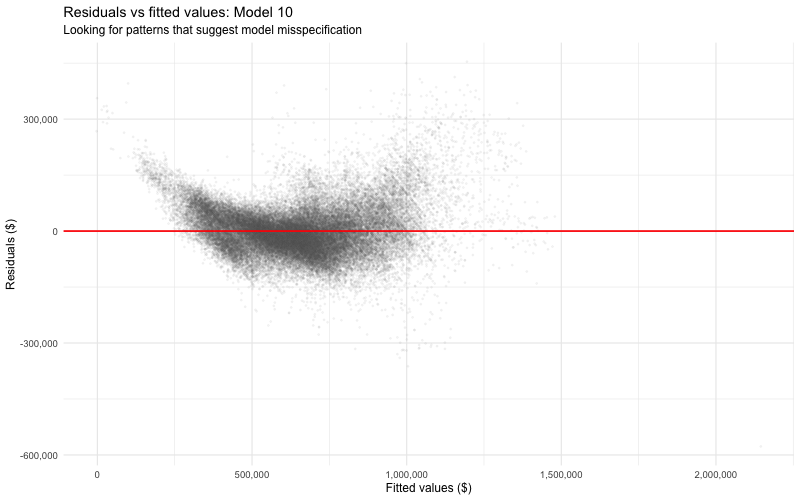

In [67]:
%%R -w 800 -h 500
aug5 <- augment(model10)

ggplot(aug5, aes(x = .fitted, y = .resid)) +
  geom_point(alpha = 0.05, size = 0.5, colour = "grey40") +
  geom_hline(yintercept = 0, colour = "red", linewidth = 0.8) +
  geom_smooth(method = "loess", colour = "blue", linewidth = 0.8) +
  scale_x_continuous(labels = comma) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Residuals vs fitted values: Model 10",
    subtitle = "Looking for patterns that suggest model misspecification",
    x = "Fitted values ($)",
    y = "Residuals ($)"
  ) +
  theme_minimal(base_size = 12)

### Add predicted and residual columns to the dataframe

In [68]:
%%R
df$predicted <- predict(model10, df)
df$residual <- df$resale_price - df$predicted
df$residual_pct <- round(df$residual / df$predicted * 100, 1)

cat(sprintf("Residual stats:\n"))
cat(sprintf("  Mean residual: $%s\n", comma(round(mean(df$residual)))))
cat(sprintf("  Median residual: $%s\n", comma(round(median(df$residual)))))
cat(sprintf("  SD of residual: $%s\n", comma(round(sd(df$residual)))))
cat(sprintf("  Mean residual %%: %.1f%%\n", mean(df$residual_pct)))
cat(sprintf("  SD of residual %%: %.1f%%\n", sd(df$residual_pct)))

Residual stats:
  Mean residual: $0
  Median residual: $-5,438
  SD of residual: $62,995
  Mean residual %: 0.2%
  SD of residual %: 156.8%


### Top 20 WTF flats (highest positive residuals — sold way above predicted price)

In [69]:
%%R
wtf_flats <- df %>%
  mutate(address = paste(block, street_name)) %>%
  arrange(desc(residual)) %>%
  head(20) %>%
  select(
    town, address, flat_type, flat_model, storey_range,
    floor_area_sqm, remaining_lease_years,
    actual_price = resale_price,
    predicted_price = predicted,
    residual,
    residual_pct
  ) %>%
  mutate(
    actual_price = paste0("$", comma(actual_price)),
    predicted_price = paste0("$", comma(round(predicted_price))),
    residual = paste0("+$", comma(round(residual))),
    residual_pct = paste0("+", residual_pct, "%")
  )

cat("TOP 20 WTF FLATS: Sold way above what the model predicts\n")
cat(paste(rep("=", 80), collapse = ""), "\n\n")
print(as.data.frame(wtf_flats), row.names = FALSE)

TOP 20 WTF FLATS: Sold way above what the model predicts

            town               address flat_type        flat_model storey_range
     BUKIT MERAH      9A BOON TIONG RD    5 ROOM          Improved     25 TO 27
          BISHAN      241 BISHAN ST 22 EXECUTIVE         Apartment     07 TO 09
     BUKIT MERAH      9A BOON TIONG RD    5 ROOM          Improved     19 TO 21
         HOUGANG     221 HOUGANG ST 21 EXECUTIVE        Maisonette     04 TO 06
        CLEMENTI   445B CLEMENTI AVE 3    5 ROOM          Improved     07 TO 09
       PASIR RIS   5 CHANGI VILLAGE RD    3 ROOM          Improved     04 TO 06
     BUKIT MERAH      9B BOON TIONG RD    5 ROOM          Improved     34 TO 36
 KALLANG/WHAMPOA         54 JLN MA'MOR    3 ROOM           Terrace     01 TO 03
     BUKIT MERAH      9A BOON TIONG RD    5 ROOM          Improved     07 TO 09
 KALLANG/WHAMPOA         53 JLN MA'MOR    3 ROOM           Terrace     01 TO 03
       TOA PAYOH      118A ALKAFF CRES    4 ROOM           Mod

### Top 20 Bargain flats (most negative residuals — sold way below predicted price)

In [70]:
%%R
bargain_flats <- df %>%
  mutate(address = paste(block, street_name)) %>%
  arrange(residual) %>%
  head(20) %>%
  select(
    town, address, flat_type, flat_model, storey_range,
    floor_area_sqm, remaining_lease_years,
    actual_price = resale_price,
    predicted_price = predicted,
    residual,
    residual_pct
  ) %>%
  mutate(
    actual_price = paste0("$", comma(actual_price)),
    predicted_price = paste0("$", comma(round(predicted_price))),
    residual = paste0("-$", comma(abs(round(residual)))),
    residual_pct = paste0(residual_pct, "%")
  )

cat("TOP 20 BARGAIN FLATS: Sold way below what the model predicts\n")
cat(paste(rep("=", 80), collapse = ""), "\n\n")
print(as.data.frame(bargain_flats), row.names = FALSE)

TOP 20 BARGAIN FLATS: Sold way below what the model predicts

            town                address flat_type flat_model storey_range
 KALLANG/WHAMPOA          53 JLN MA'MOR    3 ROOM    Terrace     01 TO 03
     JURONG WEST      216A BOON LAY AVE    5 ROOM       3Gen     13 TO 15
          YISHUN      513D YISHUN ST 51    5 ROOM       3Gen     01 TO 03
     JURONG WEST      217A BOON LAY AVE    5 ROOM       3Gen     01 TO 03
     JURONG WEST      216A BOON LAY AVE    5 ROOM       3Gen     04 TO 06
     JURONG WEST      217A BOON LAY AVE    5 ROOM       3Gen     07 TO 09
     JURONG WEST      218A BOON LAY AVE    5 ROOM       3Gen     10 TO 12
     JURONG WEST      217A BOON LAY AVE    5 ROOM       3Gen     07 TO 09
        TAMPINES 608C TAMPINES NTH DR 1    5 ROOM       3Gen     10 TO 12
        TAMPINES     726 TAMPINES ST 71    5 ROOM   Improved     07 TO 09
     JURONG WEST      218D BOON LAY AVE    5 ROOM       3Gen     10 TO 12
         HOUGANG     997B BUANGKOK CRES    5 ROOM 

### Stories from the residuals

The residuals — transactions the model can't explain — are as interesting as the coefficients.

#### WTF flats: what's driving the unexplained premiums?

**Boon Tiong Road, Block 9A (Bukit Merah)** — appears 4 times in the top 20. These Improved 5-room flats sold for $1.45M–$1.65M when the model predicts $1.1M–$1.2M (30-37% above). These are near SkyTerrace@Dawson in a mature estate undergoing rejuvenation. The premium likely reflects redevelopment speculation and unblocked views — factors our model can't capture.

**Jalan Ma'mor terraces (Kallang/Whampoa)** — 3-room terrace flats selling for $950K–$1.12M when the model predicts $575K–$736K (52-65% above). These are extremely rare HDB terrace houses — essentially landed property on HDB land. Only a handful exist in Singapore. The model treats them as regular 3-room flats and massively underpredicts because it has no variable for scarcity or landed-style living.

**5 Changi Village Road** — a 3-room flat at $495K when the model predicts $102K (+385%). Changi Village is a unique heritage enclave with a lifestyle premium (seafood, beach, kampung vibe) that the `town` dummy for Pasir Ris can't capture.

#### Bargain flats: the 3Gen problem

**16 of the top 20 bargain flats are 3Gen (multi-generation) flats** — in Jurong West (Boon Lay Ave), Hougang (Buangkok Cres), and Tampines. The model predicts $975K–$1.04M but they sell for $640K–$790K (27-36% below predicted).

3Gen flats were introduced by HDB in 2013 to encourage multi-generational living. They are oversized 5-room equivalents (~120 sqm) with an extra bedroom and bathroom for elderly parents. But the market has rejected them:

- **Odd layout** — the granny room is awkwardly placed, limiting renovation flexibility
- **Too big** — the size pushes the quantum into 5-room/Executive territory without the prestige
- **Limited buyer pool** — only families with elderly parents would specifically want this layout, and they can get a regular 5-room for less
- **Stigma** — agents report that 3Gen flats take longer to sell and require price cuts

The `flat_model_grouped` coefficient partially captures this (3Gen is grouped into "Other"), but the penalty is so large ($300K+ below predicted) that the model can't fully absorb it with a single dummy.

#### What the residuals tell us about the model

The WTF flats cluster around **scarcity** (terrace houses, unique heritage locations) and **speculation** (redevelopment potential). These are factors the model has no variables for. The bargain flats cluster around **design stigma** (3Gen). Both suggest the remaining 10% of unexplained variance is driven by unit-specific and qualitative factors that no amount of additional regression variables can capture from this dataset.

---
## Key findings

### What drives HDB resale prices?

Our final model (Model 10) explains **90.2%** of the variance in HDB resale prices using 50,718 transactions from May 2024 to April 2026. Here's what matters, in order of impact:

**1. Location is destiny (R² = 0.63 from town alone)**
- Each km from the CBD costs **$16,114**
- Each 100m from the nearest MRT/LRT costs **$7,900**
- Each 100m from the nearest hawker centre costs **$2,000**
- Each 100m from an oversubscribed primary school costs **$1,000** (regular schools: no effect)

**2. Lease decay is the biggest single predictor added after location (R² jumps +13.5%)**
- The relationship is non-linear (quadratic): remaining_lease_years = +$11,072 and remaining_lease_sq = -$29
- At 90 years remaining, each year lost costs ~$5,852. At 40 years, each year costs ~$8,752. The penalty accelerates as leases get shorter.

**3. Physical attributes matter but less than you'd think**
- Each additional sqm adds **$5,568**
- Each floor up adds **$5,399**

**4. Feng shui is priced into the market**
- Each 100m farther from a columbarium/cemetery adds **$800** — after controlling for everything else
- Proximity to temples is associated with **lower** prices (-$25/m), consistent with the feng shui belief that temples carry strong yin energy
- Closer to hospital = **cheaper** (+$4/m away), suggesting the feng shui "illness" association outweighs the amenity value
- Closer to coast = **more expensive** (-$4/m), consistent with water = wealth in feng shui, but also just waterfront premium
- `park_dist_m`: **+$3/m** — closer to a park is slightly cheaper. Possibly confounded with distance from town centres.

**5. Superstition is real — but small**
- Each digit 8 in the last 4 digits of the price: **+$1,124** premium (`num_eights_tail` — excludes leading digits that reflect price level, not seller choice)
- Price contains "168" (一路发 "prosperity all the way"): **+$32,696** premium
- Block number contains digit 4: **-$10,133** discount
- Transactions during CNY month: **+$59,316** premium (festive pricing or selection effect)
- All superstition variables together add only **0.2%** to R² — statistically significant but economically small

**6. Variables tested and dropped** (working shown in Models 1-9):
- `ends_in_8` — collinear with `num_eights_tail`, created artifact negative coefficient when both included
- `num_eights_in_price` / `num_fours_in_price` — contaminated by leading digits reflecting price level. Replaced with tail-only versions.
- `num_fours_tail` — directionally correct (-$3,076) but insignificant (p = 0.33, only 276 transactions). The avoidance-of-4s story is better told descriptively: only 0.5% of prices have 4s in their last 4 digits vs 23% for 8s.
- `supermarket_dist_m`, `reservoir_dist_m`, `school_dist_m`, `funeral_dist_m`, `block_has_8`, `price_has_888`, `hungry_ghost` — insignificant after controlling for other variables
- `has_floor_4`, `has_floor_13`, `has_floor_14` — HDB data only has storey ranges, not exact floors

**7. The model is stable across time** (Notebook 7)
- The same model run on the prior 2-year window (May 2022 – April 2024) achieves R² = 0.906 — almost identical
- Key changes: the block-4 penalty nearly doubled (-$5,952 → -$10,133), the "168" premium went from insignificant to +$32,696, and the CBD distance premium grew 50% (-$10,746 → -$16,114)
- Superstition effects are **growing**, not shrinking

---


---
## Caveats

- **Endogeneity in price-digit variables.** `num_eights_tail` and `price_has_168` are *part of* the price, not independent predictors. A $688,888 flat has more 8s than a $350,000 flat partly because it's more expensive. To fix properly: instrumental variable or matched-pair design (compare same-block, same-month transactions where one price ends in 8 and another doesn't).
- **Spatial autocorrelation.** Flats near each other have correlated prices beyond what `town` captures. SEs may be too small. Clustering by town or block would be more conservative.
- **Selection bias in timing.** Hungry Ghost Month shows fewer transactions — but are those transactions a different *type* of flat?
- **MRT list includes future stations.** Some stations aren't open yet.
- **No unit-level variation.** Facing, renovation, condition, view obstruction — that's most of the remaining ~10% unexplained variance.
- **Multicollinearity.** `dist_cbd_km`, `town`, and distance variables are correlated. Individual coefficients may be unstable.
- **Correlation ≠ causation.** The entire model is associational.
- **Superstition variables add only 0.2% R².** Statistically significant because n = 50K, but tiny in explanatory power.
- **Feng shui proximity variables are the most defensible** — distance to a columbarium is genuinely exogenous. Price-digit variables are the most problematic because they're endogenous.